In [1]:
import pandas as pd

print("CODSOFT Task 2 - Exploratory Data Analysis")
print("Pandas is ready!")

CODSOFT Task 2 - Exploratory Data Analysis
Pandas is ready!


In [2]:
df = pd.read_csv("CODSOFT_Task1_Cleaned_Sales_Dataset.csv")

print("Dataset loaded successfully!")
print("Rows and columns:", df.shape)

display(df.head())

Dataset loaded successfully!
Rows and columns: (14, 8)


,Order_ID,Date,Product,Category,Quantity,Price,Customer,City
0,1001,2026-01-05,Laptop,Electronics,2.0,55000,Rahul,Hyderabad
1,1002,2026-01-07,Mouse,Accessories,5.0,700,Amit,Delhi
2,1003,2026-01-08,Keyboard,Accessories,3.0,1200,Priya,Mumbai
3,1004,2026-01-10,Monitor,Electronics,1.0,15000,Neha,Bengaluru
4,1005,2026-01-12,Laptop,Electronics,2.5,55000,Arjun,Hyderabad


In [3]:
print("Dataset Information:")
print(df.info())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Order_ID  14 non-null     int64  
 1   Date      14 non-null     object 
 2   Product   14 non-null     object 
 3   Category  14 non-null     object 
 4   Quantity  14 non-null     float64
 5   Price     14 non-null     int64  
 6   Customer  14 non-null     object 
 7   City      14 non-null     object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.0+ KB
None


In [4]:
print("Descriptive Statistics:")
display(df.describe())

Descriptive Statistics:


,Order_ID,Quantity,Price
count,14.0000,14.000000,14.000000
mean,1007.5000,2.892857,19607.142857
std,4.1833,1.642917,23874.172214
min,1001.0000,1.000000,700.000000
25%,1004.2500,2.000000,1200.000000
50%,1007.5000,2.250000,8750.000000
75%,1010.7500,4.000000,45000.000000
max,1014.0000,6.000000,55000.000000


In [5]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Order_ID    0
Date        0
Product     0
Category    0
Quantity    0
Price       0
Customer    0
City        0
dtype: int64


In [6]:
print("Correlation between numerical variables:")
display(df.corr(numeric_only=True))

Correlation between numerical variables:


,Order_ID,Quantity,Price
Order_ID,1.000000,-0.125914,0.039781
Quantity,-0.125914,1.000000,-0.475756
Price,0.039781,-0.475756,1.000000


In [7]:
print("Outlier check:")

Q1 = df[["Quantity", "Price"]].quantile(0.25)
Q3 = df[["Quantity", "Price"]].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = ((df[["Quantity", "Price"]] < lower) |
            (df[["Quantity", "Price"]] > upper))

print("\nNumber of outliers in each column:")
print(outliers.sum())

Outlier check:

Number of outliers in each column:
Quantity    0
Price       0
dtype: int64


In [8]:
print("========== BUSINESS INSIGHTS ==========")

# 1. Total sales
df["Total_Sales"] = df["Quantity"] * df["Price"]

print("\n1. Total Sales:")
print(df["Total_Sales"].sum())

# 2. Average sales
print("\n2. Average Sales per Order:")
print(df["Total_Sales"].mean())

# 3. Best-selling product by quantity
best_product = df.groupby("Product")["Quantity"].sum().sort_values(ascending=False)

print("\n3. Products by Total Quantity Sold:")
print(best_product)

# 4. Sales by category
category_sales = df.groupby("Category")["Total_Sales"].sum().sort_values(ascending=False)

print("\n4. Sales by Category:")
print(category_sales)

# 5. Sales by city
city_sales = df.groupby("City")["Total_Sales"].sum().sort_values(ascending=False)

print("\n5. Sales by City:")
print(city_sales)

========== BUSINESS INSIGHTS ==========

1. Total Sales:
551500.0

2. Average Sales per Order:
39392.857142857145

3. Products by Total Quantity Sold:
Product
Mouse         15.0
Headphones     9.0
Laptop         6.5
Keyboard       5.0
Monitor        3.0
 laptop        2.0
Name: Quantity, dtype: float64

4. Sales by Category:
Category
Electronics    512500.0
Accessories     36600.0
accessories      2400.0
Name: Total_Sales, dtype: float64

5. Sales by City:
City
Hyderabad    467500.0
Mumbai        18600.0
Pune          17400.0
Bengaluru     15000.0
 chennai      12500.0
Delhi         10500.0
Chennai       10000.0
Name: Total_Sales, dtype: float64


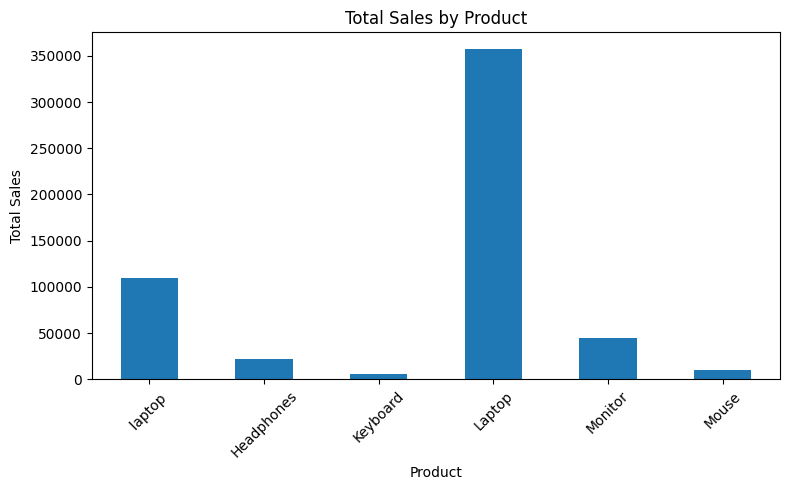

In [9]:
import matplotlib.pyplot as plt

# Sales by product
product_sales = df.groupby("Product")["Total_Sales"].sum()

plt.figure(figsize=(8, 5))
product_sales.plot(kind="bar")

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

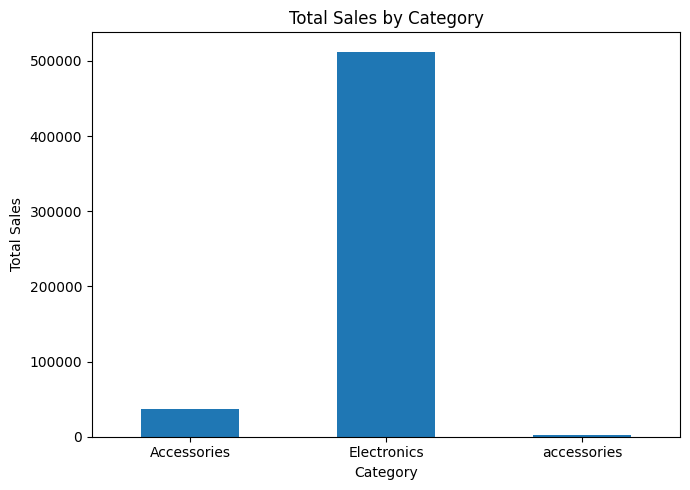

In [10]:
# Sales by category

category_sales = df.groupby("Category")["Total_Sales"].sum()

plt.figure(figsize=(7, 5))
category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

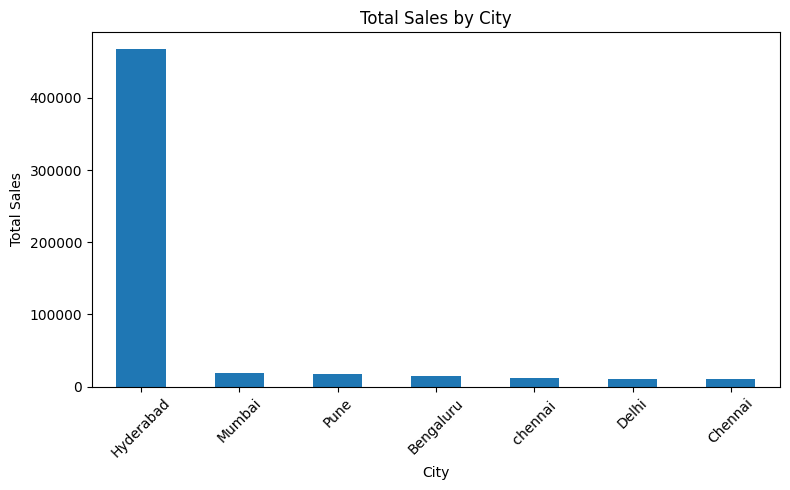

In [11]:
# Sales by city

city_sales = df.groupby("City")["Total_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
city_sales.plot(kind="bar")

plt.title("Total Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
print("========== TASK 2: EDA SUMMARY ==========")

print("\nTotal Sales:", df["Total_Sales"].sum())
print("Average Sales per Order:", df["Total_Sales"].mean())

best_product = df.groupby("Product")["Quantity"].sum().idxmax()
print("Best-selling Product:", best_product)

best_category = df.groupby("Category")["Total_Sales"].sum().idxmax()
print("Highest Sales Category:", best_category)

best_city = df.groupby("City")["Total_Sales"].sum().idxmax()
print("Highest Sales City:", best_city)

print("\n========== EDA COMPLETED ==========")
print("The dataset was analyzed using descriptive statistics,")
print("correlation analysis, outlier detection, and visualizations.")

========== TASK 2: EDA SUMMARY ==========

Total Sales: 551500.0
Average Sales per Order: 39392.857142857145
Best-selling Product: Mouse
Highest Sales Category: Electronics
Highest Sales City: Hyderabad

========== EDA COMPLETED ==========
The dataset was analyzed using descriptive statistics,
correlation analysis, outlier detection, and visualizations.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')